<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = 'mps' if torch.mps.is_available() else 'cpu'

2.9.1


## 1. What are 3 areas in industry where computer vision is currently being used?

Automotive & Autonomous Driving Systems

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

Overfitting is a modeling error in machine learning that occurs when a function is too closely fit to a limited set of data points, causing it to capture noise and random fluctuations rather than the underlying pattern

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

increasing training data, using cross-validation, applying regularization (L1/L2), reducing model complexity, dropout, and early stopping

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

In [2]:
# Done

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [3]:
from torchvision.datasets import FashionMNIST

## 6. Visualize at least 5 different samples of the MNIST training dataset.

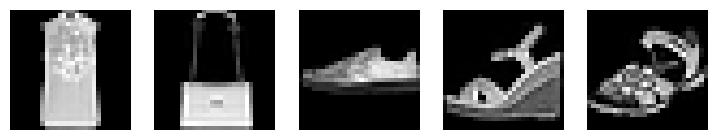

In [8]:
import matplotlib.pyplot as plt
import torch
from torchvision.transforms import ToTensor

# Vusialize a sample image from the FashionMNIST dataset
fashion_mnist = FashionMNIST(root='data',
                                train=True,
                                download=False,
                                transform=ToTensor())

fig = plt.figure(figsize=(9, 9))
rows, cols = 1,5
for i in range(1, rows*cols +1):
    random_idx = torch.randint(0, len(fashion_mnist), size=[1]).item()
    img, label = fashion_mnist[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.axis(False)

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [11]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(fashion_mnist,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(FashionMNIST(root='data',
                                         train=False,
                                         download=False,
                                         transform=ToTensor()),
                             batch_size=BATCH_SIZE,
                             shuffle=False)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [45]:
import torch.nn as nn
import torchvision
from torchvision.transforms import ToTensor
import torch

class FashionMNISTModelV0(torch.nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.layer_stack = torch.nn.Sequential(
            nn.Conv2d(in_channels=1,
                            out_channels=hidden_units,
                            kernel_size=3,
                            stride=1,
                            padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                            out_channels=hidden_units,
                            kernel_size=3,
                            stride=1,
                            padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                                stride=2),
        )
        self.layer_stack_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                        out_features=output_shape)
        )
        
    def forward(self, x: torch.Tensor):
        x = self.layer_stack(x)
        x = self.layer_stack_2(x)
        x = self.classifier(x)
        return x

model_2 = FashionMNISTModelV0(input_shape=1, hidden_units=10, output_shape=10)
model_2
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model_3 = FashionMNISTModelV0(input_shape=1, hidden_units=10, output_shape=10).to(device)
model_3

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_stack_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [58]:
from tqdm.auto import tqdm
from helper_functions import accuracy_fn
from timeit import default_timer as timer

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

def print_time_taken(start: float, end: float, device: str = "cpu"):
    total_time = end - start
    print(f'Total time on {device}: {total_time:.3f} seconds')
    return total_time

train_time_start_on_cpu = timer()
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f'Epoch: {epoch}\n-------')
    train_loss = 0.0
    for batch, (X, y) in enumerate(train_dataloader):
        model_2.train()
        y_pred = model_2(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f'Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples')
    train_loss /= len(train_dataloader)
    test_loss = 0.0
    test_acc = 0.0
    model_2.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_2(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                                    y_pred=test_pred.argmax(dim=1))
        test_loss = test_loss / len(test_dataloader)
        test_acc = test_acc / len(test_dataloader)
    print(f'Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%\n')
train_time_end_on_cpu = timer()
total_train_time_model_2 = print_time_taken(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_2.parameters()).device))

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 20%|██        | 1/5 [00:27<01:50, 27.68s/it]

Train loss: 0.55687 | Test loss: 0.40480 | Test acc: 84.94%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 40%|████      | 2/5 [00:54<01:20, 26.88s/it]

...

Train loss: 0.31782 | Test loss: 0.32202 | Test acc: 88.54%

Epoch: 3
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 80%|████████  | 4/5 [01:46<00:26, 26.59s/it]

Train loss: 0.29897 | Test loss: 0.31941 | Test acc: 88.01%

Epoch: 4
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 5/5 [02:13<00:00, 26.61s/it]

Train loss: 0.28430 | Test loss: 0.32207 | Test acc: 88.72%

Total time on cpu: 133.034 seconds


In [59]:
def eval_mode(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn):
    loss, acc = 0,0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)

            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                               y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logit -> pred_probs -> pred_labels)
        
        # Scale loss and acc to find the avare loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
    
    return {'model_name': model.__class__.__name__, # only works when model was created with class
            'model_loss': loss.item(),
            'model_acc': acc}

# Calculate model 0 results on test dataset
model_2_results = eval_mode(model=model_2, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_2_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.32207292318344116,
 'model_acc': 88.71805111821087}

### Let's try on GPU/MPS

In [49]:
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

def print_time_taken(start: float, end: float, device: str = "mps"):
    total_time = end - start
    print(f'Total time on {device}: {total_time:.3f} seconds')
    return total_time

train_time_start_on_mps = timer()
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f'Epoch: {epoch}\n-------')
    train_loss = 0.0

    for batch, (X, y) in enumerate(train_dataloader):
        model_3.train()
        X, y = X.to(device), y.to(device)
        y_pred = model_3(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f'Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples')
    train_loss /= len(train_dataloader)
    test_loss = 0.0
    test_acc = 0.0
    model_3.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            test_pred = model_3(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                                    y_pred=test_pred.argmax(dim=1))
        test_loss = test_loss / len(test_dataloader)
        test_acc = test_acc / len(test_dataloader)
    print(f'Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%\n')
train_time_end_on_mps = timer()
total_train_time_model_3 = print_time_taken(start=train_time_start_on_mps,
                                           end=train_time_end_on_mps,
                                           device=str(next(model_3.parameters()).device))

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 20%|██        | 1/5 [00:12<00:49, 12.35s/it]

Train loss: 0.80448 | Test loss: 0.82250 | Test acc: 86.38%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 40%|████      | 2/5 [00:24<00:36, 12.17s/it]

...

Train loss: 0.75651 | Test loss: 0.76709 | Test acc: 89.29%

Epoch: 3
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 80%|████████  | 4/5 [00:48<00:12, 12.12s/it]

Train loss: 0.74625 | Test loss: 0.77161 | Test acc: 89.00%

Epoch: 4
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 5/5 [01:00<00:00, 12.15s/it]

Train loss: 0.73932 | Test loss: 0.75599 | Test acc: 89.61%

Total time on mps:0: 60.739 seconds


In [51]:
def eval_mode(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn):
    loss, acc = 0,0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            # Make predictions with the model
            y_pred = model(X)

            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                               y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logit -> pred_probs -> pred_labels)
        
        # Scale loss and acc to find the avare loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
    
    return {'model_name': model.__class__.__name__, # only works when model was created with class
            'model_loss': loss.item(),
            'model_acc': acc}

# Calculate model 0 results on test dataset
model_3_results = eval_mode(model=model_3, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
model_3_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.7559941411018372,
 'model_acc': 89.60662939297124}

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

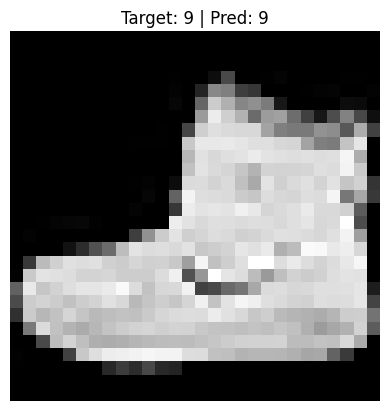

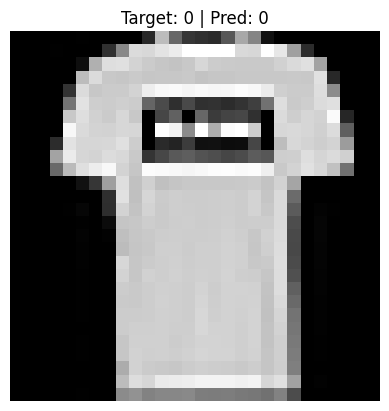

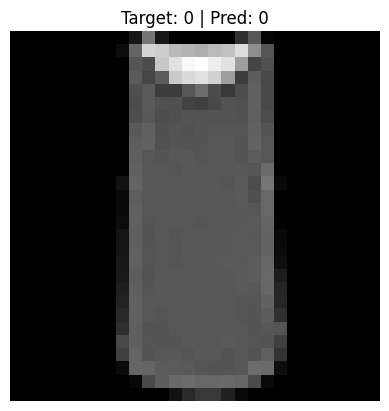

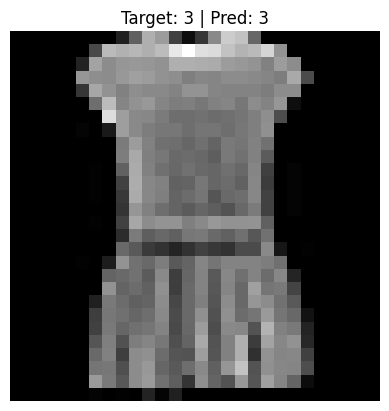

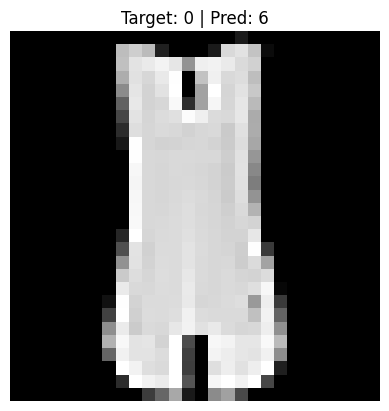

In [60]:
# Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label
for i in range(5):
    img, label = fashion_mnist[i]
    model_2.eval()
    with torch.inference_mode():
        pred_logit = model_2(img.unsqueeze(0))
        pred_label = pred_logit.argmax(dim=1).item()
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f'Target: {label} | Pred: {pred_label}')
    plt.axis(False)
    plt.show()

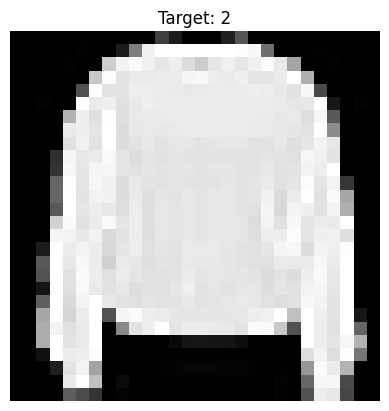

In [66]:
img, label = fashion_mnist[7]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f'Target: {label}')
plt.axis(False)
plt.show()

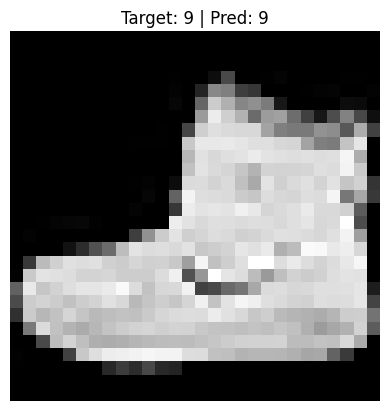

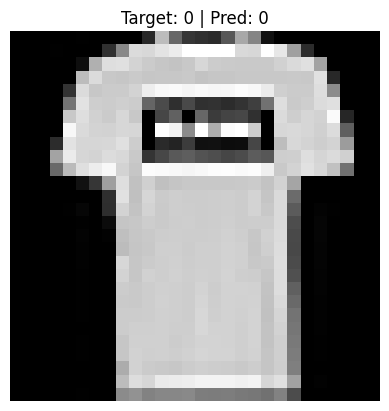

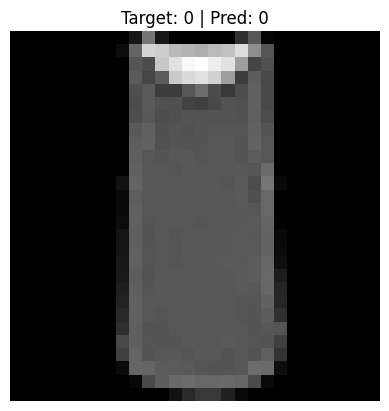

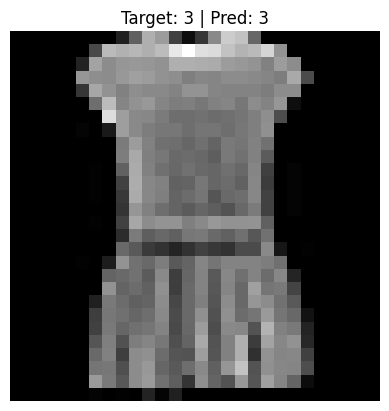

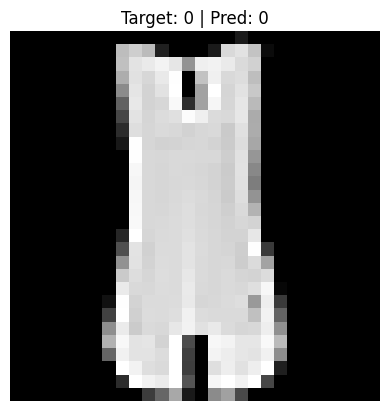

In [54]:
for i in range(5):
    img, label = fashion_mnist[i]
    model_3.eval()
    with torch.inference_mode():
        pred_logit = model_3(img.unsqueeze(0).to(device))
        pred_label = pred_logit.argmax(dim=1).item()
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f'Target: {label} | Pred: {pred_label}')
    plt.axis(False)
    plt.show()

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

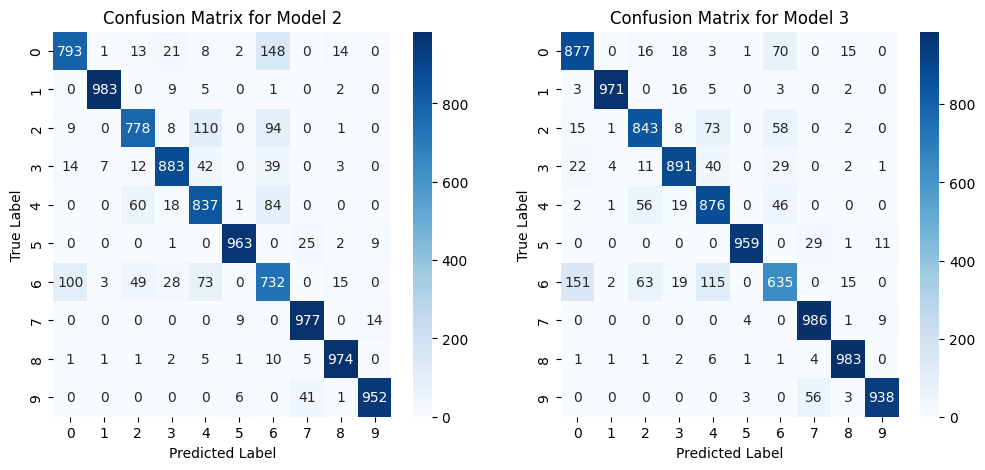

In [61]:
# Confusion matrix comparing model_2 and model_3 results
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
y_true = []
y_pred_model_2 = []
y_pred_model_3 = []
model_2.eval()
model_3.eval()
with torch.inference_mode():
    for X, y in test_dataloader:
        # model_2 is on CPU, model_3 is on MPS
        preds_2 = model_2(X).argmax(dim=1)  # X stays on CPU for model_2
        preds_3 = model_3(X.to(device)).argmax(dim=1)  # X moved to MPS for model_3
        y_true.extend(y.numpy())
        y_pred_model_2.extend(preds_2.numpy())
        y_pred_model_3.extend(preds_3.cpu().numpy())
cm_model_2 = confusion_matrix(y_true, y_pred_model_2)
cm_model_3 = confusion_matrix(y_true, y_pred_model_3)
df_cm_model_2 = pd.DataFrame(cm_model_2,
                             index=[i for i in range(10)],
                             columns=[i for i in range(10)])
df_cm_model_3 = pd.DataFrame(cm_model_3,
                             index=[i for i in range(10)],
                             columns=[i for i in range(10)])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(df_cm_model_2, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Model 2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.subplot(1, 2, 2)
sns.heatmap(df_cm_model_3, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Model 3')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Model Comparison Results:
Model 2 (CPU):              88.72%
Model 3 (MPS):              89.59%
Ensemble (Soft Voting):     90.22%
Ensemble (Hard Voting):     90.06%


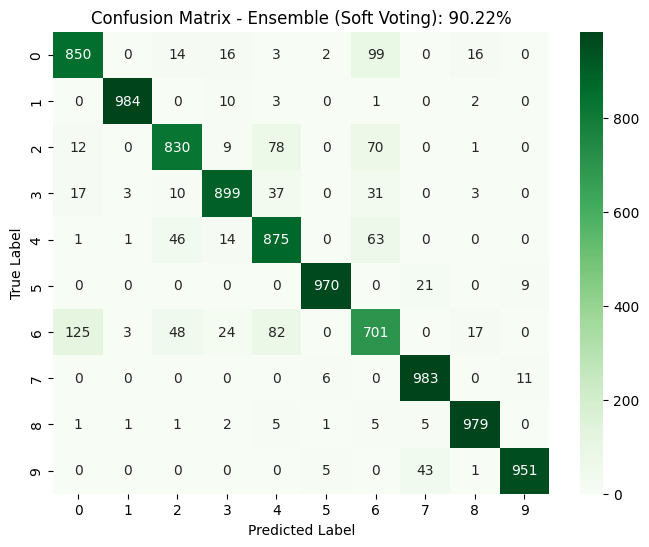

In [62]:
# Ensemble: Combine predictions from both models for better results
from torch.nn.functional import softmax

y_true = []
y_pred_ensemble_avg = []  # Average probabilities (soft voting)
y_pred_ensemble_vote = []  # Majority voting (hard voting)

model_2.eval()
model_3.eval()

with torch.inference_mode():
    for X, y in test_dataloader:
        # Get logits from both models
        logits_2 = model_2(X)  # CPU
        logits_3 = model_3(X.to(device)).cpu()  # MPS -> CPU
        
        # Convert to probabilities
        probs_2 = softmax(logits_2, dim=1)
        probs_3 = softmax(logits_3, dim=1)
        
        # Method 1: Average probabilities (soft voting)
        avg_probs = (probs_2 + probs_3) / 2
        preds_avg = avg_probs.argmax(dim=1)
        
        # Method 2: Majority voting (hard voting) - if they disagree, use the higher confidence
        preds_2 = logits_2.argmax(dim=1)
        preds_3 = logits_3.argmax(dim=1)
        
        # For hard voting: when predictions differ, pick the one with higher confidence
        max_conf_2 = probs_2.max(dim=1).values
        max_conf_3 = probs_3.max(dim=1).values
        preds_vote = torch.where(max_conf_2 >= max_conf_3, preds_2, preds_3)
        
        y_true.extend(y.numpy())
        y_pred_ensemble_avg.extend(preds_avg.numpy())
        y_pred_ensemble_vote.extend(preds_vote.numpy())

# Calculate accuracies
acc_model_2 = (torch.tensor(y_pred_model_2) == torch.tensor(y_true)).float().mean() * 100
acc_model_3 = (torch.tensor(y_pred_model_3) == torch.tensor(y_true)).float().mean() * 100
acc_ensemble_avg = (torch.tensor(y_pred_ensemble_avg) == torch.tensor(y_true)).float().mean() * 100
acc_ensemble_vote = (torch.tensor(y_pred_ensemble_vote) == torch.tensor(y_true)).float().mean() * 100

print("="*50)
print("Model Comparison Results:")
print("="*50)
print(f"Model 2 (CPU):              {acc_model_2:.2f}%")
print(f"Model 3 (MPS):              {acc_model_3:.2f}%")
print(f"Ensemble (Soft Voting):     {acc_ensemble_avg:.2f}%")
print(f"Ensemble (Hard Voting):     {acc_ensemble_vote:.2f}%")
print("="*50)

# Plot confusion matrix for best ensemble
cm_ensemble = confusion_matrix(y_true, y_pred_ensemble_avg)
df_cm_ensemble = pd.DataFrame(cm_ensemble, index=range(10), columns=range(10))

plt.figure(figsize=(8, 6))
sns.heatmap(df_cm_ensemble, annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - Ensemble (Soft Voting): {acc_ensemble_avg:.2f}%')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [87]:
tensor1 = torch.rand(5,3,64,64)
result = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=1, padding=1)(tensor1)
result.shape

torch.Size([5, 10, 64, 64])

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?